In [ ]:
# Ctrl + Shift + P > Format cell : formatear la celda. La identacion de los loops debe ser correcta
# Ctrl + J : Abrir terminal

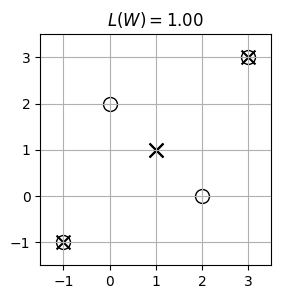

In [ ]:
import numpy as np; import matplotlib.pyplot as plt
X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ]); N = len(X);
K = 1; _, _, Vt = np.linalg.svd(X - X.mean(0)); W = Vt[:K, :].T; Z = X @ W; hX = Z @ W.T
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3)); ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5]); plt.grid(True); ax.set_title(f'$L(W)={L:.2f}$')
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');

# Dijamos dimension final 2
# Vt = SBD de matriz de datos. Calculamos W, matriz de proyección, cogiendo los k primeros vectores
# Z: matriz d datos proyectada a una dimension. La reconstruimos y nos da hX
# Con ambas matrices calculamos la diferencia. El resultado lo volvemos a representar

# Hemos perdido un poco de información al comprimirla y descomprimirla (hay 3 puntos, en vez de 4)


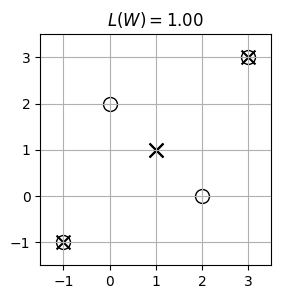

In [ ]:
import numpy as np; import matplotlib.pyplot as plt; from sklearn.decomposition import PCA
X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ]); N = len(X)
K = 1; pca = PCA(n_components=K).fit(X - X.mean(0)); Z = pca.transform(X)
hX = pca.inverse_transform(Z); L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3)); ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5]); plt.grid(True); ax.set_title(f'$L(W)={L:.2f}$')
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');

# importamos PCA desde sklearn. Lo utilizamos llamandolo pasando las dimensiones.
# Este ejemplo nos muestra que podemos rabajar con sklearn, que funciona igual y nos facilitara la vida
# fit: caclula la matriz de proyeccion
# transform: proyecta la matriz

<br>


# MNIST

In [19]:
# MNIST: dataset
import numpy as np; import datasets
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy"); ds


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [ ]:
train0 = ds["train"][0]
train0["image"].shape, train0["image"].dtype, train0["label"]

((28, 28), dtype('uint8'), np.int64(5))

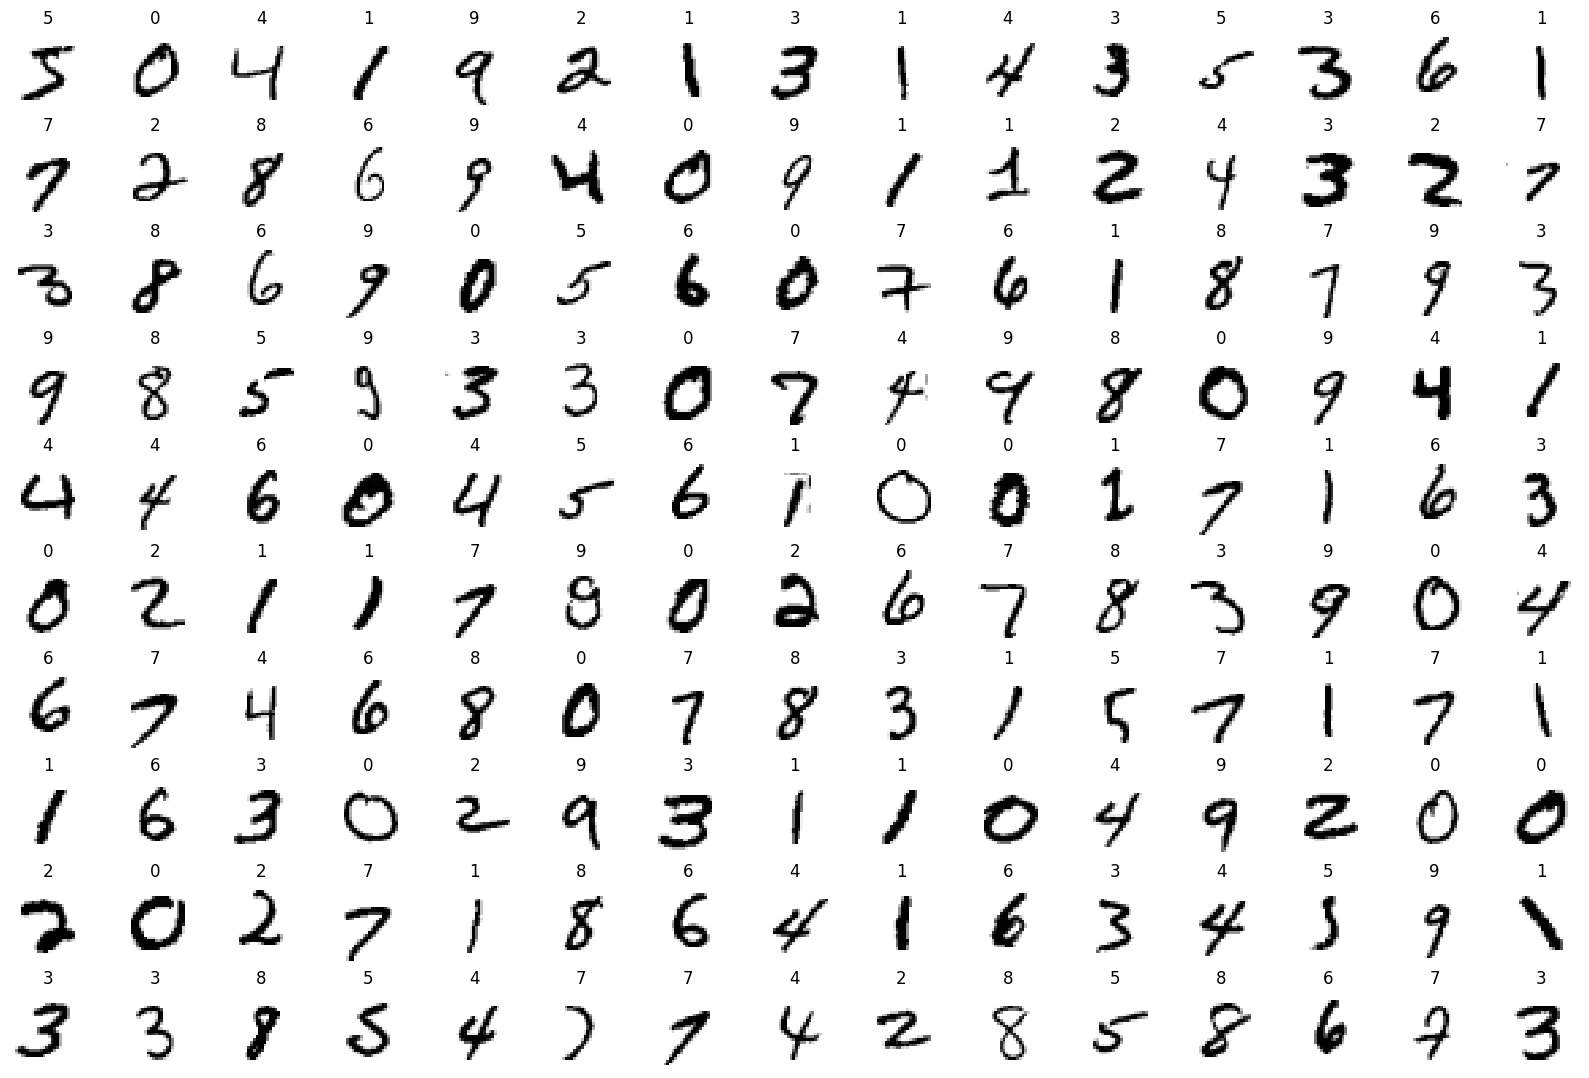

In [21]:
import matplotlib.pyplot as plt

nrows = 10
ncols = 15
N = nrows * ncols
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(y)

In [ ]:
# PCA  aplicado a MNIST: estudio del error de reconstruccion en funcion de K
import numpy as np
import datasets

ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
ds
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

# X_train: samples de entrenamiento
# Y_train: clases de entrenamiento

In [ ]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

# La grafica resultante dice que. al teneer 774 dimensiones, conforme vamos reduciendo las dimensiones el error / diferencia entre
# la compresión y la matriz original va a ser mayor. Es decir, utilizar sobre 500 de dimension para
# conseguir un buen procesamiento y un buen coste. Más dimensinoes no mejoraría el procesameinto y costaróa mas
# y menos dimensiones daria más error

In [ ]:
# Eigendigits y reconstruccion con dimension K

K = 400
pca = PCA(n_components=K).fit(X_train)
nrows, ncols = 1, 10
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none"
    )

# cada vector propcio se especializa en detectar unas caracterisitcas concretas. El Eigendigit 0 se especializa en detectar 0s, por ejemplo (blanco = mas importante)

NameError: name 'X_train' is not defined

In [ ]:
# precision de regresion logistica
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.1, max_iter=200).fit(Z_train[:, :K], y_train)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
    plt.figure(figsize=(9, 2.5))
    plt.grid(True)
    plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m")

# El maximo esta en 500, no en 800. Esto es debido al SOBREENTRENAMIENTO: el modelo se abruma
#
#

NameError: name 'X_train' is not defined

In [ ]:
# Ahora aplicaremos PCA a Fashion-MNIST

import numpy as np; import datasets
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy"); ds

ModuleNotFoundError: No module named 'datasets'

In [ ]:
import matplotlib.pyplot as plt

nrows = 4
ncols = 15
N = nrows * ncols
labels = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(labels[y])

In [ ]:
# diferencias de CIFAR-10 con respecto al resto de datasets
#   las imagenes se llaman 'img' 
#   el reshape no funciona, al ser 32x32*3, en vez de 28*28

X_train = ds['train'][:]['img'].astype(np.float32).reshape(-1, 32*32*3) / 255.
y_train = ds['train'][:]['label'].astype(np.uint8)
X_test = ds['test'][:]['img'].astype(np.float32).reshape(-1, 32*32*3) / 255.
y_test = ds['test'][:]['label'].astype(np.uint8)